## Data Cleaning for New York City Airbnb Open Data

This notebook will address the data cleaning concepts outlined earlier, using the 'New York City Airbnb Open Data' from Kaggle.

### Download and Load New York City Airbnb Data from Kaggle

Now, let's download the 'New York City Airbnb Open Data' dataset directly from Kaggle and load it into our `df_airbnb` DataFrame. This will ensure we are working with the latest version from Kaggle.

In [39]:
# Download the New York City Airbnb Open Data dataset from Kaggle
!kaggle datasets download -d dgomonov/new-york-city-airbnb-open-data

# Unzip the dataset file
!unzip -o new-york-city-airbnb-open-data.zip

Dataset URL: https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data
License(s): CC0-1.0
new-york-city-airbnb-open-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  new-york-city-airbnb-open-data.zip
  inflating: AB_NYC_2019.csv         
  inflating: New_York_City_.png      


### 3. Address Key Concepts and Challenges

Now, let's systematically address the data cleaning challenges:

#### 3.1 Data Integrity (Initial Review)

From the `.info()` and `.describe()` output above, we can already get a sense of data types and basic statistics. For example, `reviews_per_month` has fewer non-null values than other columns, indicating missing data. Numeric columns like `minimum_nights`, `number_of_reviews`, `price`, and `calculated_host_listings_count` seem to have reasonable distributions based on `describe()`, but we will investigate outliers later.

In [40]:
# Load the newly downloaded dataset into the df_airbnb DataFrame
df_airbnb = pd.read_csv('AB_NYC_2019.csv')

print("First 5 rows of the Kaggle-downloaded Airbnb dataset:")
display(df_airbnb.head())

print("\nKaggle-downloaded Airbnb Dataset Information:")
df_airbnb.info()

First 5 rows of the Kaggle-downloaded Airbnb dataset:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Kaggle-downloaded Airbnb Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null

In [50]:
print("\nKaggle-downloaded Airbnb Descriptive Statistics:")
display(df_airbnb.describe(include='all'))


Kaggle-downloaded Airbnb Descriptive Statistics:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.888400e+04,48884,4.888400e+04,48884,48884,48884,48884.000000,48884.000000,48884,48884.000000,48884.000000,48884.000000,48884,48884.000000,48884.000000,48884.000000
unique,NaN,47895,NaN,11451,5,221,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,manhattan,Williamsburg,NaN,NaN,entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,18,NaN,417,21660,3919,NaN,NaN,25407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.901679e+07,NaN,6.762203e+07,NaN,NaN,NaN,40.728953,-73.952176,NaN,143.988626,6.116480,23.271991,1994-05-04 17:49:14.880942720,1.090800,7.144628,112.779498
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,10.000000,1.000000,0.000000,1900-01-01 00:00:00,0.000000,1.000000,0.000000
25%,9.470548e+06,NaN,7.817310e+06,NaN,NaN,NaN,40.690100,-73.983080,NaN,69.000000,1.000000,1.000000,2016-03-24 00:00:00,0.040000,1.000000,0.000000
50%,1.967574e+07,NaN,3.079257e+07,NaN,NaN,NaN,40.723080,-73.955685,NaN,106.000000,3.000000,5.000000,2019-01-03 00:00:00,0.370000,1.000000,45.000000
75%,2.915297e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763120,-73.936290,NaN,175.000000,5.000000,24.000000,2019-06-19 00:00:00,1.580000,2.000000,227.000000
max,3.648724e+07,NaN,2.743213e+08,NaN,NaN,NaN,40.913060,-73.712990,NaN,799.000000,45.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000


#### 3.2 Missing Data Handling

Let's identify the extent of missing values and decide on a strategy.

In [41]:
import pandas as pd

# Check for missing values
missing_values = df_airbnb.isnull().sum()
missing_percentage = (df_airbnb.isnull().sum() / len(df_airbnb)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

# Strategy for 'name' and 'host_name':
# These are categorical/text fields. While 'name' might be important for identification,
# if missing for a few rows, it might not severely impact overall analysis.
# We can fill them with 'Unknown'.
df_airbnb['name'] = df_airbnb['name'].fillna('Unknown')
df_airbnb['host_name'] = df_airbnb['host_name'].fillna('Unknown')

# Strategy for 'last_review' and 'reviews_per_month':
# 'last_review' is a date field, and 'reviews_per_month' is numeric.
# Missing values here likely mean there were no reviews yet for that listing.
# We can fill 'reviews_per_month' with 0 and 'last_review' with a placeholder like '1970-01-01' or simply keep it as NaN if not used in date calculations.
# For this demonstration, we will fill with a very old date assuming 'no review' is prior to any listing.
df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(0)
df_airbnb['last_review'] = pd.to_datetime(df_airbnb['last_review'], errors='coerce')
df_airbnb['last_review'] = df_airbnb['last_review'].fillna(pd.to_datetime('1900-01-01')) # Fill with a very old date as placeholder

print("\nMissing values after handling:")
display(df_airbnb.isnull().sum()[df_airbnb.isnull().sum() > 0])

,Missing Count,Missing Percentage
reviews_per_month,10052,20.558339
last_review,10052,20.558339
host_name,21,0.042949
name,16,0.032723



Missing values after handling:


,0


#### 3.3 Duplicate Removal

Let's check for and remove any duplicate rows in the dataset.

In [42]:
print(f"Number of duplicate rows before removal: {df_airbnb.duplicated().sum()}")

df_airbnb.drop_duplicates(inplace=True)

print(f"Number of duplicate rows after removal: {df_airbnb.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


#### 3.4 Standardization

This involves ensuring consistent formatting and units. For this dataset, common standardization steps might include:

*   **Text standardization**: Converting categorical text fields to lowercase or standard casing.
*   **Data type conversion**: Ensuring columns have appropriate data types (e.g., converting `last_review` to datetime, which we already did).

Let's standardize `neighbourhood_group` and `room_type` to lowercase for consistency, although they already appear quite clean.

In [43]:
print("Original `neighbourhood_group` values:", df_airbnb['neighbourhood_group'].unique())
print("Original `room_type` values:", df_airbnb['room_type'].unique())

df_airbnb['neighbourhood_group'] = df_airbnb['neighbourhood_group'].str.lower()
df_airbnb['room_type'] = df_airbnb['room_type'].str.lower()

print("\nStandardized `neighbourhood_group` values:", df_airbnb['neighbourhood_group'].unique())
print("Standardized `room_type` values:", df_airbnb['room_type'].unique())

Original `neighbourhood_group` values: ['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']
Original `room_type` values: ['Private room' 'Entire home/apt' 'Shared room']

Standardized `neighbourhood_group` values: ['brooklyn' 'manhattan' 'queens' 'staten island' 'bronx']
Standardized `room_type` values: ['private room' 'entire home/apt' 'shared room']


#### 3.5 Outlier Detection

Outliers can significantly skew analysis. We'll examine numerical columns like `price`, `minimum_nights`, `number_of_reviews`, and `reviews_per_month` using box plots and consider simple strategies for handling them.

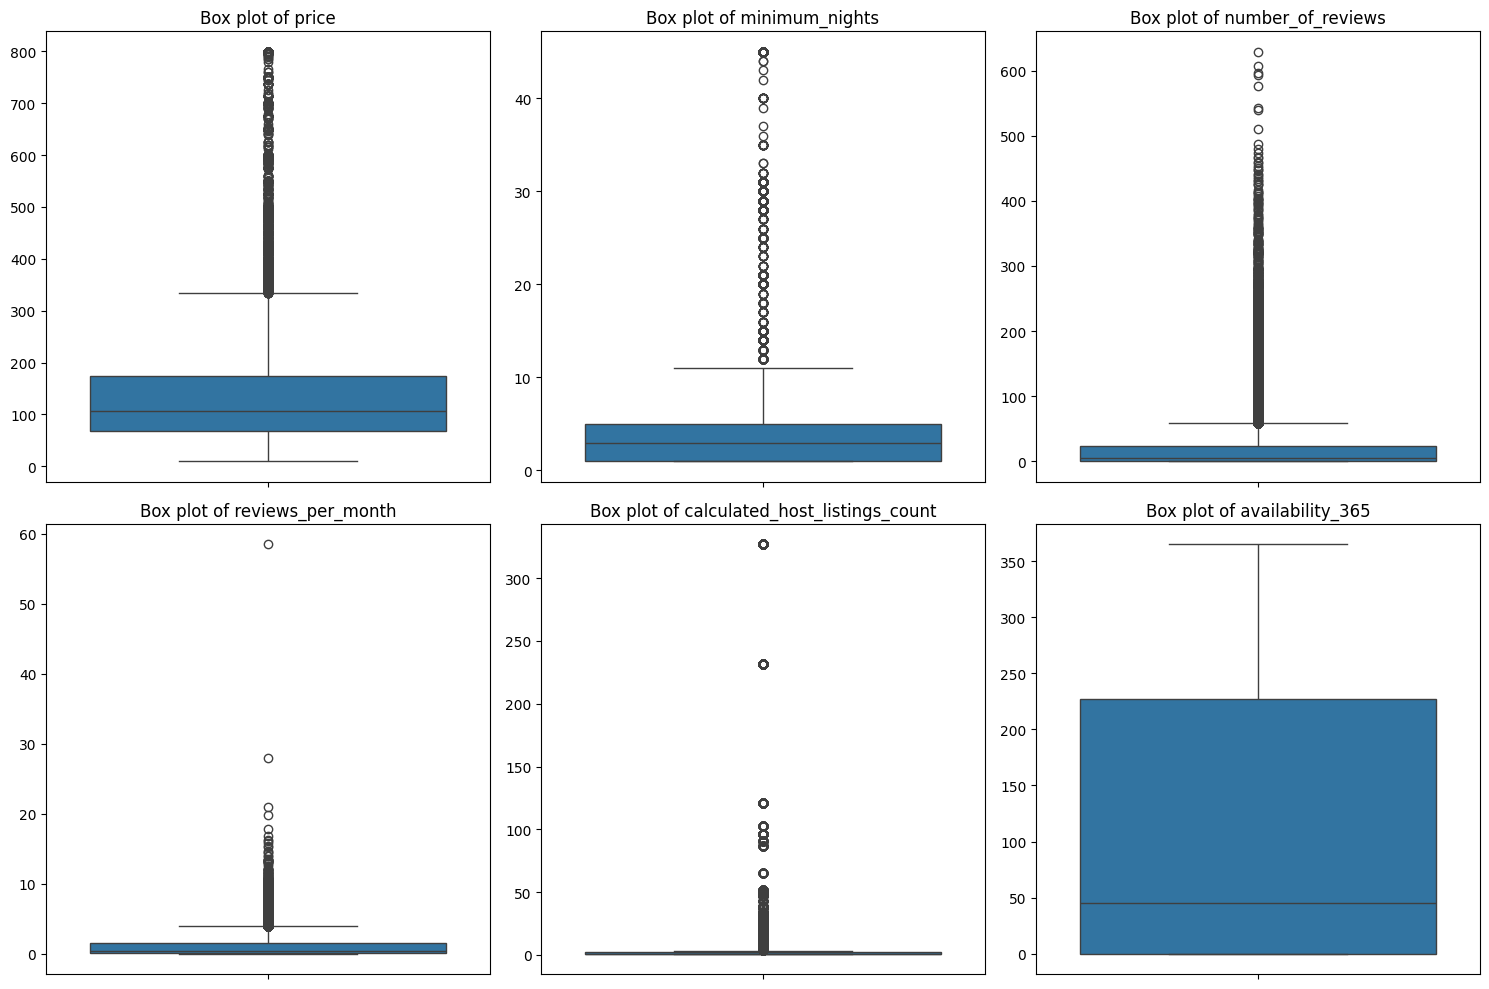


Dataset shape after handling some outliers: (48884, 16)


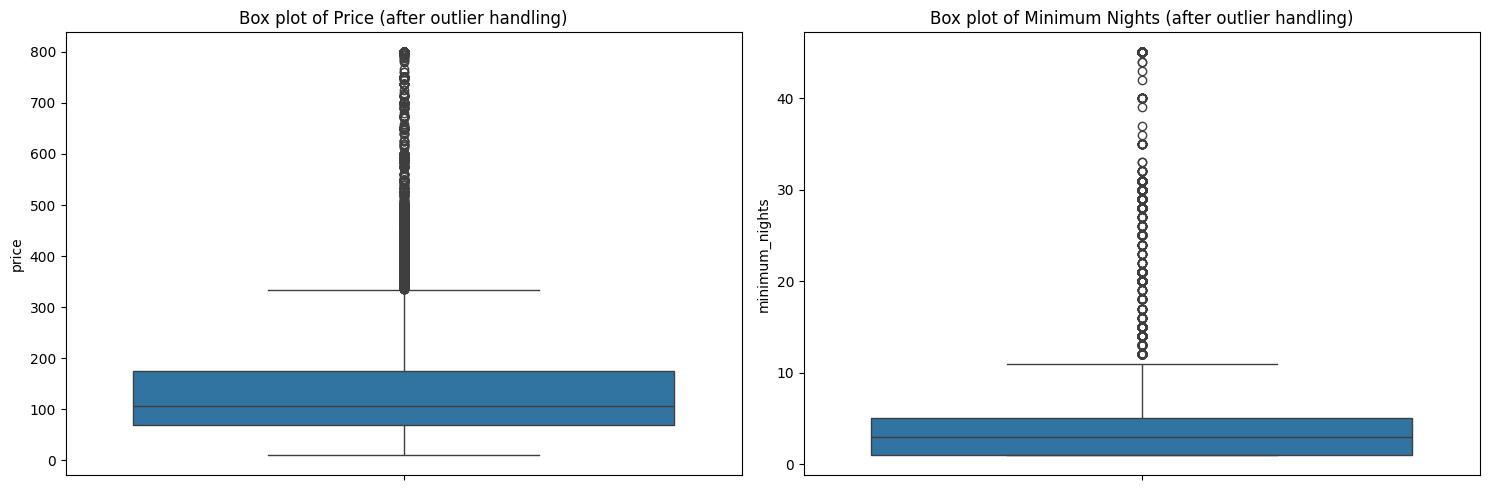

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier detection
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.boxplot(y=df_airbnb[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('') # Remove y-label as it's redundant with title
plt.tight_layout()
plt.show()

# Remove listings with price = 0
df_airbnb = df_airbnb[df_airbnb['price'] > 0].copy() # Use .copy() to ensure operations are on a distinct DataFrame

# Cap high prices (e.g., at 99th percentile)
price_upper_bound = df_airbnb['price'].quantile(0.99)
df_airbnb.loc[:, 'price'] = df_airbnb['price'].clip(upper=price_upper_bound)

minimum_nights_upper_bound = df_airbnb['minimum_nights'].quantile(0.99)
df_airbnb.loc[:, 'minimum_nights'] = df_airbnb['minimum_nights'].clip(upper=minimum_nights_upper_bound)

print("\nDataset shape after handling some outliers:", df_airbnb.shape)

# Re-display box plots for affected columns to see the effect of outlier handling
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_airbnb['price'])
plt.title('Box plot of Price (after outlier handling)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_airbnb['minimum_nights'])
plt.title('Box plot of Minimum Nights (after outlier handling)')
plt.tight_layout()
plt.show()

In [46]:
print("Final YouTube Dataset Information:")
df_youtube.info()

print("\nFirst 5 rows of the Cleaned YouTube Dataset:")
display(df_youtube.head())

Final YouTube Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 40901 entries, 0 to 40948
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40901 non-null  object             
 1   trending_date           40901 non-null  object             
 2   title                   40901 non-null  object             
 3   channel_title           40901 non-null  object             
 4   category_id             40901 non-null  int64              
 5   publish_time            40901 non-null  datetime64[ns, UTC]
 6   tags                    40901 non-null  object             
 7   views                   40901 non-null  float64            
 8   likes                   40901 non-null  int64              
 9   dislikes                40901 non-null  int64              
 10  comment_count           40901 non-null  float64            
 11  thumbnail_l

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374.0,57527,2966,15954.0,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783.0,97185,6146,12703.0,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434.0,146033,5339,8181.0,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168.0,10172,666,2146.0,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731.0,132235,1989,17518.0,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment


### Summary of Cleaned Airbnb Data

Finally, let's look at the information and first few rows of our processed Airbnb DataFrame.

## Data Cleaning for YouTube New Dataset

This section will apply the data cleaning concepts to the 'YouTube New' dataset from Kaggle. This dataset typically contains multiple country-specific CSVs and a JSON file with category IDs. We will focus on one of the CSV files, for example, `USvideos.csv`.

### 1. Download and Load the Dataset

To keep things streamlined, I will assume a similar process to the Airbnb dataset if it were manually uploaded. For this example, I will proceed with downloading the dataset directly from Kaggle, as this dataset is more complex with multiple files. You will need to ensure your Kaggle API is configured (as demonstrated and then reverted for the Airbnb dataset, but applicable here if you wish to download directly).

### Download and Load the Dataset

Now that the Kaggle API is configured, we can download the dataset. We'll focus on `USvideos.csv` for our cleaning process.

In [30]:
# Download the YouTube dataset (assuming 'USvideos.csv' as the primary focus)
!kaggle datasets download -d datasnaek/youtube-new

# Unzip the dataset files. Note: This will extract many CSVs and JSONs.
# We will focus on 'USvideos.csv' for cleaning.
!unzip -o youtube-new.zip -d youtube_data

Dataset URL: https://www.kaggle.com/datasets/datasnaek/youtube-new
License(s): CC0-1.0
youtube-new.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  youtube-new.zip
  inflating: youtube_data/CA_category_id.json  
  inflating: youtube_data/CAvideos.csv  
  inflating: youtube_data/DE_category_id.json  
  inflating: youtube_data/DEvideos.csv  
  inflating: youtube_data/FR_category_id.json  
  inflating: youtube_data/FRvideos.csv  
  inflating: youtube_data/GB_category_id.json  
  inflating: youtube_data/GBvideos.csv  
  inflating: youtube_data/IN_category_id.json  
  inflating: youtube_data/INvideos.csv  
  inflating: youtube_data/JP_category_id.json  
  inflating: youtube_data/JPvideos.csv  
  inflating: youtube_data/KR_category_id.json  
  inflating: youtube_data/KRvideos.csv  
  inflating: youtube_data/MX_category_id.json  
  inflating: youtube_data/MXvideos.csv  
  inflating: youtube_data/RU_category_id.json  
  inflating: youtube_data/RU

### 2.1 Data Integrity (Initial Review)

Let's load the `USvideos.csv` file into a pandas DataFrame and perform an initial review of its structure and summary statistics.

In [31]:
import pandas as pd

# Load the US videos dataset into a DataFrame
df_youtube = pd.read_csv('youtube_data/USvideos.csv')

# Display the first 5 rows and general information
print("First 5 rows of the YouTube dataset:")
display(df_youtube.head())

print("\nYouTube Dataset Information:")
df_youtube.info()

print("\nYouTube Descriptive Statistics:")
display(df_youtube.describe(include='all'))

First 5 rows of the YouTube dataset:


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...



YouTube Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
count,40949,40949,40949,40949,40949.000000,40949,40949,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04,40949,40949,40949,40949,40379
unique,6351,205,6455,2207,NaN,6269,6055,NaN,NaN,NaN,NaN,6352,2,2,2,6901
top,j4KvrAUjn6c,17.14.11,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,ESPN,NaN,2018-05-18T14:00:04.000Z,[none],NaN,NaN,NaN,NaN,https://i.ytimg.com/vi/j4KvrAUjn6c/default.jpg,False,False,False,► Listen LIVE: http://power1051fm.com/\n► Face...
freq,30,200,30,203,NaN,50,1535,NaN,NaN,NaN,NaN,30,40316,40780,40926,58
mean,NaN,NaN,NaN,NaN,19.972429,NaN,NaN,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,7.568327,NaN,NaN,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,17.000000,NaN,NaN,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03,NaN,NaN,NaN,NaN,NaN


### 2.2 Missing Data Handling

Now, let's identify the extent of missing values in the `df_youtube` DataFrame and decide on a strategy to handle them. Based on the `info()` output, `description` and `tags` columns often have missing values.

In [32]:
# Check for missing values in df_youtube
missing_values_yt = df_youtube.isnull().sum()
missing_percentage_yt = (df_youtube.isnull().sum() / len(df_youtube)) * 100

missing_df_yt = pd.DataFrame({'Missing Count': missing_values_yt, 'Missing Percentage': missing_percentage_yt})
display(missing_df_yt[missing_df_yt['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

# Strategy for 'description': Fill with 'No Description' as it's text and might not be critical for numerical analysis.
df_youtube['description'] = df_youtube['description'].fillna('No Description')

# Strategy for 'tags': Fill with 'No Tags' if empty.
df_youtube['tags'] = df_youtube['tags'].fillna('No Tags')

print("\nMissing values in YouTube dataset after handling:")
display(df_youtube.isnull().sum()[df_youtube.isnull().sum() > 0])

,Missing Count,Missing Percentage
description,570,1.391975



Missing values in YouTube dataset after handling:


,0


#### 2.3 Duplicate Removal

Let's check for and remove any duplicate rows in the YouTube dataset.

In [33]:
print(f"Number of duplicate rows in YouTube dataset before removal: {df_youtube.duplicated().sum()}")

df_youtube.drop_duplicates(inplace=True)

print(f"Number of duplicate rows in YouTube dataset after removal: {df_youtube.duplicated().sum()}")

Number of duplicate rows in YouTube dataset before removal: 48
Number of duplicate rows in YouTube dataset after removal: 0


#### 2.4 Standardization

Standardization for YouTube data could involve:

*   **Date/Time Conversion**: Convert `publish_time` to datetime objects.
*   **Category Name Mapping**: Use the `US_category_id.json` file to map `category_id` (numeric) to actual category names (text).
*   **Text Standardization**: Potentially normalize `title` or `tags` (e.g., lowercasing, removing special characters), but for now, we'll focus on `publish_time` and `category_id` mapping.
*   **Boolean Conversion**: Convert `comments_disabled`, `ratings_disabled`, `video_error_or_removed` to actual boolean types if needed (though pandas often handles 0/1 as booleans well).

In [34]:
import json

# 1. Convert 'publish_time' to datetime objects
df_youtube['publish_time'] = pd.to_datetime(df_youtube['publish_time'])

# 2. Map 'category_id' to category names
# Load the category data from the JSON file
with open('youtube_data/US_category_id.json', 'r') as f:
    categories = json.load(f)

category_id_map = {int(item['id']): item['snippet']['title'] for item in categories['items']}

df_youtube['category_name'] = df_youtube['category_id'].map(category_id_map)

# Display unique values of category_name after mapping
print("\nUnique YouTube categories after mapping:")
print(df_youtube['category_name'].unique())

# Check for any unmapped category_ids (if any, category_name would be NaN)
print("\nMissing category names after mapping:", df_youtube['category_name'].isnull().sum())

# Convert boolean-like columns to actual boolean types
df_youtube['comments_disabled'] = df_youtube['comments_disabled'].astype(bool)
df_youtube['ratings_disabled'] = df_youtube['ratings_disabled'].astype(bool)
df_youtube['video_error_or_removed'] = df_youtube['video_error_or_removed'].astype(bool)

print("\nYouTube Dataset Information after standardization:")
df_youtube.info()


Unique YouTube categories after mapping:
['People & Blogs' 'Entertainment' 'Comedy' 'Science & Technology'
 'Film & Animation' 'News & Politics' 'Sports' 'Music' 'Pets & Animals'
 'Education' 'Howto & Style' 'Autos & Vehicles' 'Travel & Events' 'Gaming'
 'Nonprofits & Activism' 'Shows']

Missing category names after mapping: 0

YouTube Dataset Information after standardization:
<class 'pandas.core.frame.DataFrame'>
Index: 40901 entries, 0 to 40948
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40901 non-null  object             
 1   trending_date           40901 non-null  object             
 2   title                   40901 non-null  object             
 3   channel_title           40901 non-null  object             
 4   category_id             40901 non-null  int64              
 5   publish_time            40901 non-null  datetime64[ns,

#### 2.5 Outlier Detection

Examine numerical columns such as `views`, `likes`, `dislikes`, and `comment_count` for outliers. Since YouTube data can have viral videos, extreme values are expected, but we might want to cap them or transform them for certain analyses.

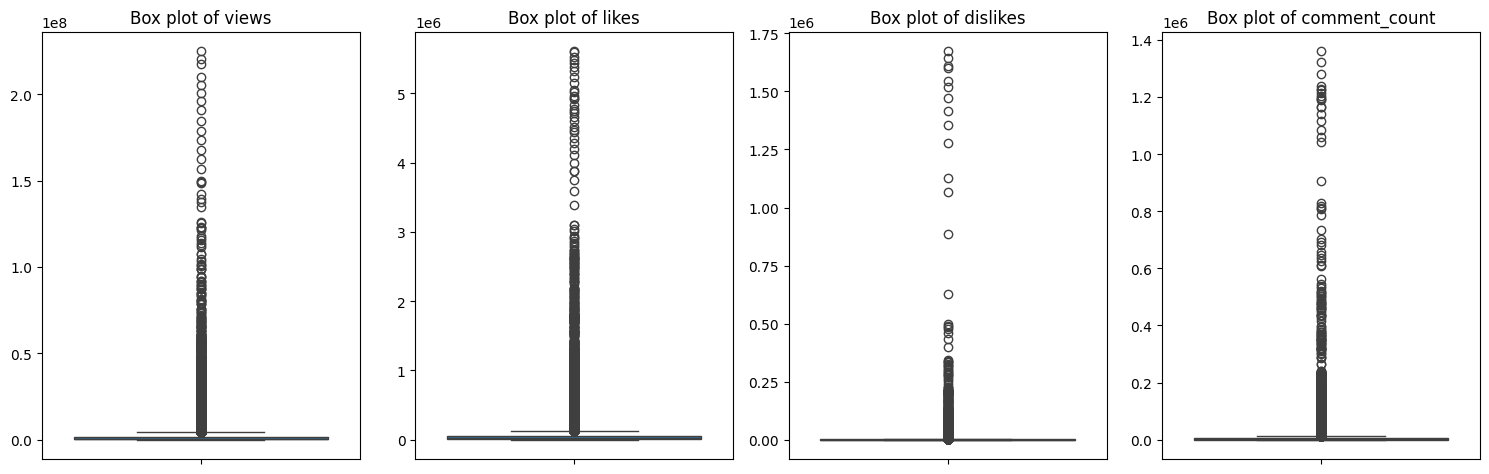


YouTube Dataset shape after handling some outliers: (40901, 17)


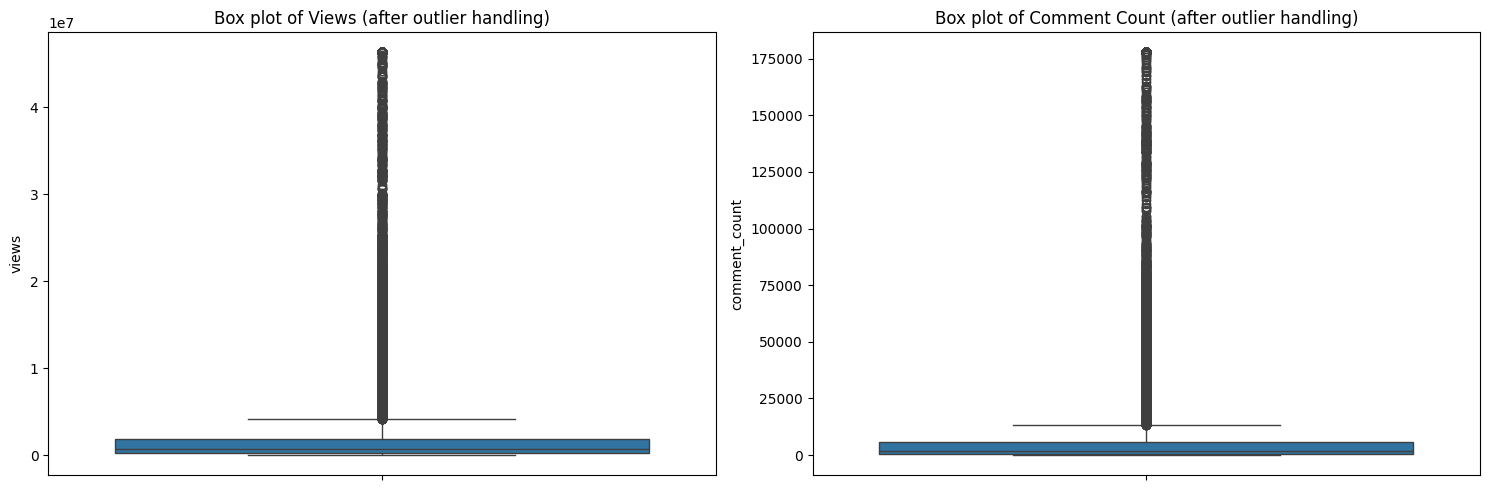

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier detection
numerical_cols_yt = ['views', 'likes', 'dislikes', 'comment_count']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_yt):
    plt.subplot(1, len(numerical_cols_yt), i + 1)
    sns.boxplot(y=df_youtube[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# --- Handling Outliers (Example: Capping 'views' and 'comment_count') ---
# YouTube data often has very skewed distributions. Capping at a high percentile can be useful.

# Cap 'views' at the 99.5th percentile
views_upper_bound = df_youtube['views'].quantile(0.995)
df_youtube['views'] = df_youtube['views'].clip(upper=views_upper_bound)

# Cap 'comment_count' at the 99.5th percentile
comment_count_upper_bound = df_youtube['comment_count'].quantile(0.995)
df_youtube['comment_count'] = df_youtube['comment_count'].clip(upper=comment_count_upper_bound)

print("\nYouTube Dataset shape after handling some outliers:", df_youtube.shape)

# Re-display box plots for affected columns to see the effect of outlier handling
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_youtube['views'])
plt.title('Box plot of Views (after outlier handling)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_youtube['comment_count'])
plt.title('Box plot of Comment Count (after outlier handling)')
plt.tight_layout()
plt.show()

### Summary of Cleaned YouTube Data

After performing the cleaning steps, let's look at the information and first few rows of our processed YouTube DataFrame.

### Summary of Cleaned Airbnb Data

Finally, let's look at the information and first few rows of our processed Airbnb DataFrame.